**LangGraph**

In [1]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from agents.flight.agent import flight_graph as graph

**Test**

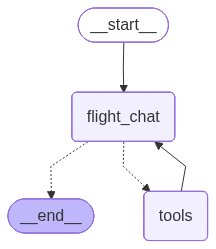

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	flight_chat(flight_chat)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> flight_chat;
	flight_chat -.-> __end__;
	flight_chat -.-> tools;
	tools --> flight_chat;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass
# 1. In ra mã nguồn Mermaid của graph
mermaid_code = graph.get_graph(xray=True).draw_mermaid()
print(mermaid_code)

In [2]:
def stream_graph_updates(inputs: dict):
    for event in graph.stream(inputs):
        if "flight_chat" in event:
            messages = event["flight_chat"].get("messages", [])
            for msg in messages:
                # Nếu là AIMessage (object)
                if hasattr(msg, "content") and msg.content:
                    print("Assistant:", msg.content)
                # Nếu là dict
                elif isinstance(msg, dict) and msg.get("role") == "assistant":
                    print("Assistant:", msg.get("content"))
        if "tools" in event:
            messages = event["tools"].get("messages", [])
            for msg in messages:
                if hasattr(msg, "content") and msg.content:
                    print("Tool Output:", msg.content)
                elif isinstance(msg, dict):
                    print("Tool Output:", msg.get("content"))

In [4]:
test_cases = [
    # --- Test Cases for Searching ---
    # Test 1: Tìm kiếm với nhiều điều kiện
    "Tôi muốn kiếm chuyến bay khởi hành từ Sài Gòn đến Đà Nẵng vào ngày 2026-06-20.",
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi muốn kiếm chuyến bay khởi hành từ Sài Gòn đến Đà Nẵng vào ngày 2026-06-20.
CALL API: https://booking-com15.p.rapidapi.com/api/v1/flights/searchDestination
PARAMS: {'query': 'Sài Gòn', 'languagecode': 'vi'}
FINAL URL: https://booking-com15.p.rapidapi.com/api/v1/flights/searchDestination?query=S%C3%A0i+G%C3%B2n&languagecode=vi
Tool Output: [{"error": "Lỗi khi gọi flight searchDestination: RapidAPI bị giới hạn request. Hãy thử lại sau."}]
Assistant: Tôi xin lỗi, hiện tại tôi không thể tìm chuyến bay vào lúc này. Vui lòng thử lại sau.



In [4]:
test_cases = [
    # --- Test Cases for Searching ---
    # Test 1: Tìm kiếm với nhiều điều kiện
    "Tôi muốn kiếm chuyến bay từ Hà Nội đến Đà Nẵng.",
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi muốn kiếm chuyến bay từ Hà Nội đến Đà Nẵng.
Executing semantic search with filters...
Qdrant semantic search: Found 6 results
Tool Output: [{"flight_id": "VN101", "departure_airport_id": "SGN", "arrival_airport_id": "HAN", "airline_id": "VN", "departure_time": "2025-02-20T08:00:00", "arrival_time": "2025-02-20T10:10:00", "city_depart": "Sài Gòn", "city_arrive": "Hà Nội", "airline_name": "Vietnam Airlines", "airport_name_depart": "Tân Sơn Nhất International Airport", "airport_name_arrive": "Nội Bài International Airport"}, {"flight_id": "VJ302", "departure_airport_id": "HAN", "arrival_airport_id": "DAD", "airline_id": "VJ", "departure_time": "2025-02-20T13:30:00", "arrival_time": "2025-02-20T14:45:00", "city_depart": "Hà Nội", "city_arrive": "Đà Nẵng", "airline_name": "VietJet Air", "airport_name_depart": "Nội Bài International Airport", "airport_name_arrive": "Đà Nẵng International Airport"}, {"flight_id": "VJ889", "departure_airport_id": "PQC", "arrival_airport_id": "SGN

In [3]:
test_cases = [
    # --- Test Cases for Searching ---
    # Test 1: Tìm kiếm với nhiều điều kiện
    "Tìm giúp tôi chuyến bay từ sân bay SGN đến sân bay HAN.",
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tìm giúp tôi chuyến bay từ sân bay SGN đến sân bay HAN.
Collection 'flights_v2' already exists. Skipping creation.
Collection 'flight_prices' already exists. Skipping creation.
Collection 'passengers' already exists. Skipping creation.
Collection 'bookings' already exists. Skipping creation.
Collection 'tickets' already exists. Skipping creation.
Found 6 existing flights points in Qdrant.
 Qdrant (Flights) is up-to-date. No new flights to index.
Found 12 existing flight prices points in Qdrant.
 Qdrant (Flight Prices) is up-to-date. No flight prices to index.
Found 4 existing bookings points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Found 13 existing tickets points in Qdrant.
 Qdrant (Tickets) is up-to-date. No new tickets to index.
Executing filter-only search with Qdrant...
Qdrant filter-only search: Found 1 results
Tool Output: [{"flight_id": "VN101", "departure_airport_id": "SGN", "arrival_airport_id": "HAN", "airline_id": "VN", "departure_tim

In [ ]:
test_cases = [
    # --- Test Cases for Searching ---
    # Test 1: Tìm kiếm với nhiều điều kiện
    "Có chuyến bay nào đáp xuống Phú Quốc trong ngày không?",
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Có chuyến bay nào đáp xuống Phú Quốc trong ngày không?
Executing semantic search with filters...
Qdrant semantic search: Found 1 results
Tool Output: [{"flight_id": "VN611", "departure_airport_id": "DLI", "arrival_airport_id": "PQC", "airline_id": "VN", "departure_time": "2025-02-20 11:20", "arrival_time": "2025-02-20 12:05", "city_depart": "Đà Lạt", "city_arrive": "Phú Quốc", "airline_name": "Vietnam Airlines", "airport_name_depart": "Liên Khương Airport", "airport_name_arrive": "Phu Quoc International Airport"}]
Assistant: Có, có một chuyến bay đến Phú Quốc trong ngày:

Chuyến bay VN611 của Vietnam Airlines, khởi hành từ sân bay Liên Khương (Đà Lạt) lúc 11:20 và đến sân bay Quốc tế Phú Quốc (Phú Quốc) lúc 12:05.



In [5]:
test_cases = [
    # --- Test Cases for Searching ---
    # Test 1: Tìm kiếm với nhiều điều kiện
    "Tôi cần chuyến bay từ Đà Lạt đi Phú Quốc vào thời gian 20/2/2025.",
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi cần chuyến bay từ Đà Lạt đi Phú Quốc vào thời gian 20/2/2025.
Collection 'flights_v2' already exists. Skipping creation.
Collection 'flight_prices' already exists. Skipping creation.
Collection 'passengers' already exists. Skipping creation.
Collection 'bookings' already exists. Skipping creation.
Collection 'tickets' already exists. Skipping creation.
Found 6 existing flights points in Qdrant.
 Qdrant (Flights) is up-to-date. No new flights to index.
Found 12 existing flight prices points in Qdrant.
 Qdrant (Flight Prices) is up-to-date. No flight prices to index.
Found 4 existing bookings points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Found 13 existing tickets points in Qdrant.
 Qdrant (Tickets) is up-to-date. No new tickets to index.
Executing semantic search with filters...
Qdrant semantic search: Found 6 results
Tool Output: [{"flight_id": "VJ302", "departure_airport_id": "HAN", "arrival_airport_id": "DAD", "airline_id": "VJ", "departur

In [3]:
test_cases = [
    # --- Test Cases for Searching ---
    # Test 1: Tìm kiếm với nhiều điều kiện
    "Tôi cần chuyến bay từ Đà Lạt đi Phú Quốc vào thời gian khởi hành 11:20 giờ sáng.",
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi cần chuyến bay từ Đà Lạt đi Phú Quốc vào thời gian khởi hành 11:20 giờ sáng.
Collection 'flights_v2' already exists. Skipping creation.
Collection 'flight_prices' already exists. Skipping creation.
Collection 'passengers' already exists. Skipping creation.
Collection 'bookings' already exists. Skipping creation.
Collection 'tickets' already exists. Skipping creation.
Found 6 existing flights points in Qdrant.
 Qdrant (Flights) is up-to-date. No new flights to index.
Found 12 existing flight prices points in Qdrant.
 Qdrant (Flight Prices) is up-to-date. No flight prices to index.
Found 4 existing bookings points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Found 13 existing tickets points in Qdrant.
 Qdrant (Tickets) is up-to-date. No new tickets to index.
Executing semantic search with filters...
Qdrant search failed: sequence item 2: expected str instance, NoneType found, falling back to exact search
Exact search (flights): Found 0 results
Assi

In [7]:
test_cases = [
    # --- Test Cases for Flight Price Search ---

    # Test 1: Hỏi giá vé hạng phổ thông (eco) của 1 chuyến cụ thể
    "Cho tôi hỏi giá tiền vé phổ thông  của chuyến VN101.",
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Cho tôi hỏi giá tiền vé phổ thông  của chuyến VN101.
 Qdrant semantic search: Found 1 results
Tool Output: [{"flight_id": "VN101", "seat_type": "economy", "price": 1200000, "seat_quota": 120}]
Assistant: Giá vé phổ thông của chuyến VN101 là 1.200.000 VNĐ.



In [5]:
test_cases = [
    # --- Test Cases for Flight Price Search ---

    # Test 1: Hỏi giá vé hạng phổ thông (eco) của 1 chuyến cụ thể
    "Cho tôi xem giá tất cả của chuyến bay VN101.",
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Cho tôi xem giá tất cả của chuyến bay VN101.
 Qdrant semantic search: Found 2 results
Tool Output: [{"flight_id": "VN101", "seat_type": "business", "price": 3500000, "seat_quota": 16}, {"flight_id": "VN101", "seat_type": "eco", "price": 1200000, "seat_quota": 120}]
Assistant: Chuyến bay VN101 có các mức giá sau:
* Ghế thương gia: 3.500.000 VNĐ (còn 16 ghế)
* Ghế phổ thông: 1.200.000 VNĐ (còn 120 ghế)



In [4]:
test_cases = [
    # --- Test Cases for Flight Price Search ---

    # Test 1: Hỏi giá vé hạng phổ thông (eco) của 1 chuyến cụ thể
    "Tôi muốn đặt vé chuyến bay VN101, hạng economy cho 4 người.",
    # "Tôi cập nhập tên khách hàng cho vé BKG004. Người 1 tên Nguyễn Văn A, CMND 12345678. Người 2 tên Trần Thị B, CCCD 987654321. Ngươif thứ 3 tên Phan Kn, CMND 12345. Người thứ 4 tên Nguyễn N, CMND 123456777123456777"
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi muốn đặt vé chuyến bay VN101, hạng economy cho 4 người.
Collection 'flights_v2' already exists. Skipping creation.
Collection 'flight_prices' already exists. Skipping creation.
Collection 'passengers' already exists. Skipping creation.
Collection 'bookings' already exists. Skipping creation.
Collection 'tickets' already exists. Skipping creation.
Found 6 existing flights points in Qdrant.
 Qdrant (Flights) is up-to-date. No new flights to index.
Found 18 existing flight prices points in Qdrant.
 Qdrant (Flight Prices) is up-to-date. No flight prices to index.
Found 4 existing bookings points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Found 13 existing tickets points in Qdrant.
 Qdrant (Tickets) is up-to-date. No new tickets to index.
DEBUG: price_info = {'flight_id': 'VN101', 'seat_type': 'economy', 'price': 1200000, 'seat_quota': 120}, type = <class 'dict'>
DEBUG: Generated ticket 1: T008
DEBUG: Generated ticket 2: T009
DEBUG: Generated ticket

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 15.402993403s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 13.06869752s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 13
}
]

In [3]:
test_cases = [
    # --- Test Cases for Flight Price Search ---

    # Test 1: Hỏi giá vé hạng phổ thông (eco) của 1 chuyến cụ thể
   
    "Tôi cập nhập tên khách hàng cho vé BKG004. Người 1 tên Nguyễn Văn A, CMND 12345678, dob 1990-01-01, quốc tịch Việt Nam. Người 2 tên Trần Thị B, CCCD 987654321, dob 1990-01-01, quốc tịch Việt Nam. Ngươif thứ 3 tên Phan Kn, CMND 12345, dob 1990-01-01, quốc tịch Việt Nam. Người thứ 4 tên Nguyễn N, CMND 123456777123456777, dob 1990-01-01 , quốc tịch Việt Nam."
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi cập nhập tên khách hàng cho vé BKG004. Người 1 tên Nguyễn Văn A, CMND 12345678, dob 1990-01-01, quốc tịch Việt Nam. Người 2 tên Trần Thị B, CCCD 987654321, dob 1990-01-01, quốc tịch Việt Nam. Ngươif thứ 3 tên Phan Kn, CMND 12345, dob 1990-01-01, quốc tịch Việt Nam. Người thứ 4 tên Nguyễn N, CMND 123456777123456777, dob 1990-01-01 , quốc tịch Việt Nam.
Collection 'flights_v2' already exists. Skipping creation.
Collection 'flight_prices' already exists. Skipping creation.
Collection 'passengers' already exists. Skipping creation.
Collection 'bookings' already exists. Skipping creation.
Collection 'tickets' already exists. Skipping creation.
Found 6 existing flights points in Qdrant.
 Qdrant (Flights) is up-to-date. No new flights to index.
Found 12 existing flight prices points in Qdrant.
 Qdrant (Flight Prices) is up-to-date. No flight prices to index.
Found 0 existing bookings points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Found 13 existing 

In [3]:
test_cases = [
    # --- Test Cases for Flight Price Search ---

    # Test 1: Hỏi giá vé hạng phổ thông (eco) của 1 chuyến cụ thể
    "Tôi muốn hủy booking BKG005.",
    # "Tôi cập nhập tên khách hàng cho vé BKG004. Người 1 tên Nguyễn Văn A, CMND 12345678. Người 2 tên Trần Thị B, CCCD 987654321. Ngươif thứ 3 tên Phan Kn, CMND 12345. Người thứ 4 tên Nguyễn N, CMND 123456777123456777"
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi muốn hủy booking BKG005.
Collection 'flights_v2' already exists. Skipping creation.
Collection 'flight_prices' already exists. Skipping creation.
Collection 'passengers' already exists. Skipping creation.
Collection 'bookings' already exists. Skipping creation.
Collection 'tickets' already exists. Skipping creation.
Found 6 existing flights points in Qdrant.
 Qdrant (Flights) is up-to-date. No new flights to index.
Found 12 existing flight prices points in Qdrant.
 Qdrant (Flight Prices) is up-to-date. No flight prices to index.
Found 16 existing bookings points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Found 33 existing tickets points in Qdrant.
 Qdrant (Tickets) is up-to-date. No new tickets to index.
Found 6 existing flights points in Qdrant.
 Qdrant (Flights) is up-to-date. No new flights to index.
Found 12 existing flight prices points in Qdrant.
 Qdrant (Flight Prices) is up-to-date. No flight prices to index.
Found 16 existing bookings 

In [4]:
test_cases = [
    # --- Test Cases for Flight Price Search ---

    # Test 1: Hỏi giá vé hạng phổ thông (eco) của 1 chuyến cụ thể
    "Tôi muốn đặt chuyến bay VN101, hạng thương gia cho 2 người.",
    # "Tôi cập nhập tên khách hàng cho vé BKG004. Người 1 tên Nguyễn Văn A, CMND 12345678. Người 2 tên Trần Thị B, CCCD 987654321. Ngươif thứ 3 tên Phan Kn, CMND 12345. Người thứ 4 tên Nguyễn N, CMND 123456777123456777"
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi muốn đặt chuyến bay VN101, hạng thương gia cho 2 người.
Collection 'flights_v2' already exists. Skipping creation.
Collection 'flight_prices' already exists. Skipping creation.
Collection 'passengers' already exists. Skipping creation.
Collection 'bookings' already exists. Skipping creation.
Collection 'tickets' already exists. Skipping creation.
Found 6 existing flights points in Qdrant.
 Qdrant (Flights) is up-to-date. No new flights to index.
Found 18 existing flight prices points in Qdrant.
 Qdrant (Flight Prices) is up-to-date. No flight prices to index.
Found 5 existing bookings points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Found 13 existing tickets points in Qdrant.
 Qdrant (Tickets) is up-to-date. No new tickets to index.
Executing filter-only search with Qdrant...
Qdrant filter-only search: Found 1 results
Tool Output: [{"flight_id": "VN101", "departure_airport_id": "SGN", "arrival_airport_id": "HAN", "airline_id": "VN", "departure

In [3]:
test_cases = [
    # --- Test Cases for Flight Price Search ---
    "Tôi muốn đặt chuyến bay VJ302, hạng phổ thông cho 2 người.",
   
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi muốn đặt chuyến bay VJ302, hạng phổ thông cho 2 người.
Collection 'flights_v2' not found. Creating...
 Collection 'flights_v2' created successfully.
Collection 'flight_prices' not found. Creating...
 Collection 'flight_prices' created successfully.
Collection 'passengers' already exists. Skipping creation.
Collection 'bookings' already exists. Skipping creation.
Collection 'tickets' already exists. Skipping creation.
Found 0 existing flights points in Qdrant.
Indexing 6 new flights...
 Successfully indexed 6 flights to Qdrant.
Found 0 existing flight prices points in Qdrant.
 Indexing 12 flight prices...
 Successfully indexed 12 flight prices to Qdrant.
Found 16 existing bookings points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Found 33 existing tickets points in Qdrant.
 Qdrant (Tickets) is up-to-date. No new tickets to index.
DEBUG: price_info = {'flight_id': 'VJ302', 'seat_type': 'economy', 'price': 900000, 'seat_quota': 140}, type = <class

In [4]:
test_cases = [
    # --- Test Cases for Flight Price Search ---
    "Tôi muốn đặt chuyến bay VJ302, hạng phổ thông cho 3 người.",
   
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi muốn đặt chuyến bay VJ302, hạng phổ thông cho 3 người.
DEBUG: price_info = {'flight_id': 'VJ302', 'seat_type': 'economy', 'price': 900000, 'seat_quota': 138}, type = <class 'dict'>
DEBUG: Looking for flight_id='VJ302', seat_type='economy'
DEBUG: flight_prices has 12 records
DEBUG: FOUND! Updated seat_quota from 138 to 135
DEBUG: Cache updated for VJ302/economy
DEBUG: Qdrant collection updated for VJ302/economy
DEBUG: Generated ticket 1: T011
DEBUG: Generated ticket 2: T012
DEBUG: Generated ticket 3: T013
Tool Output: Booking confirmed with ID BKG006. Tickets created: T011, T012, T013. Total price: 2700000 . Please provide passenger details for each ticket. The information of the passengers is in the format of a list of dictionaries with the following keys: passenger_name, date_of_birth, id_type, id_number, nationality.
Assistant: Bạn đã đặt thành công chuyến bay VJ302, hạng phổ thông cho 3 người. Mã đặt chỗ của bạn là BKG006. Các vé đã được tạo là T011, T012, T013. Tổng g